# **Visualización de imagenes con NiMare** 
**Autor:** *Pablo De León Devia*

**github:** *@deleonpablo*


<img src="assets/niMare.png" width=500 height= 400 />


## **Objetivo**  
Mapear de forma exitosa las comparaciones entre la infromación recolectada en papers y el estandar de montecarlo 
A traves de algoritmos de meta analisis como **Multikernel Data Analysis (MKDA)**  y **ALE (Activation likelihood Estimation)**


## **Proceso** 
- Dividir los papers entre depresión o biplaridad
- Generar subconjuntos de estudios de cambios estructurales vs. cambios funcionales
- Extraer información y montarla en la *base de datos* (JSON correspondiente)
- Correr algoritmos de comparación (ALE) o (MKDA)

## **Paso 1: Extracción de la información.**

Generar excel con toda la información que fue solicitada, Incluyendo la división entre los estudios. 
**CORRER CELDA DE CODIGO PARA VISUALIZAR LAS PRIMERAS 5 FILAS DE CADA PAGINA DEL EXCEL**

In [16]:
import xlwings as xw
import pandas as pd
from IPython.display import display


pd.set_option('display.max_columns', None)

wb = xw.Book('NIMARE_Campos_Esenciales_v2.xlsx')

for i, sheet in enumerate(wb.sheets):
    print(f"--- Pagina {i}: {sheet.name} ---")
    df = sheet.used_range.options(pd.DataFrame, index=False).value
    if df is not None:
        display(df.head(5))
    else:
        print("Sheet is empty.")

--- Pagina 0: GUIA_DE_CAMPOS ---


,GUÍA DE CAMPOS — META-ANÁLISIS NIMARE,NaN,NaN,NaN,NaN,NaN,NaN
0,"Qué significa cada campo, dónde encontrarlo en...",NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,🔴 CAMPOS OBLIGATORIOS (9) — Sin cualquiera de...,NaN,NaN,NaN,NaN,NaN,NaN
3,CAMPO,QUÉ SIGNIFICA,DÓNDE ENCONTRARLO EN EL PAPER,CÓMO SE VE EN EL PAPER,EJEMPLO DE VALOR,VALORES POSIBLES,POR QUÉ ES OBLIGATORIO / NOTAS
4,study_id,Identificador único que TÚ asignas a cada estu...,NO aparece en el paper. Tú lo construyes con l...,No aplica. Ejemplo de construcción:\nZheng (au...,Zheng2023_MDD_Fun,Texto sin espacios. Usa _ para separar partes.,⚠️ CRÍTICO: Debe ser IDÉNTICO en todas las fil...


--- Pagina 1: Depresion_Estructural ---


,META-ANÁLISIS NIMARE · DEPRESIÓN – ESTRUCTURAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,🔴 Columnas ROJAS (9) = OBLIGATORIAS — Sin cual...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study_id,x,y,z,n_total,space,effect_direction,modality_subtype,med_status,first_author,year,n_patients,n_controls,stat_threshold,source_location
2,Ej: Smith2022_MDD_Str,Número MNI,Número MNI,Número MNI,Pac + Ctrl,MNI o TAL,INCREASE o DECREASE,VBM / dFC / rs-fMRI,naïve / medicated,Apellido,YYYY,Solo pac.,Solo ctrl.,p<0.05 + método,Table X / Suppl. SX
3,Shuran2017_MDD_Str,8.0,18.0,-26.0,168.0,MNI,DECREASE,VBM,Medication-naïve,NaN,NaN,NaN,NaN,NaN,NaN
4,Shuran2017_MDD_Str,-10.0,53.0,6.0,168.0,MNI,DECREASE,VBM,Medication-naïve,NaN,NaN,NaN,NaN,NaN,NaN


--- Pagina 2: Depresion_Funcional ---


...

,META-ANÁLISIS NIMARE · BIPOLAR – ESTRUCTURAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,🔴 Columnas ROJAS (9) = OBLIGATORIAS — Sin cual...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study_id,x,y,z,n_total,space,effect_direction,modality_subtype,med_status,first_author,year,n_patients,n_controls,stat_threshold,source_location
2,Ej: Smith2022_MDD_Str,Número MNI,Número MNI,Número MNI,Pac + Ctrl,MNI o TAL,INCREASE o DECREASE,VBM / dFC / rs-fMRI,naïve / medicated,Apellido,YYYY,Solo pac.,Solo ctrl.,p<0.05 + método,Table X / Suppl. SX
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Pagina 4: Bipolar_Funcional ---


,META-ANÁLISIS NIMARE · BIPOLAR – FUNCIONAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,🔴 Columnas ROJAS (9) = OBLIGATORIAS — Sin cual...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study_id,x,y,z,n_total,space,effect_direction,modality_subtype,med_status,first_author,year,n_patients,n_controls,stat_threshold,source_location
2,Ej: Smith2022_MDD_Str,Número MNI,Número MNI,Número MNI,Pac + Ctrl,MNI o TAL,INCREASE o DECREASE,VBM / dFC / rs-fMRI,naïve / medicated,Apellido,YYYY,Solo pac.,Solo ctrl.,p<0.05 + método,Table X / Suppl. SX
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Pagina 5: SIN COORDENADAS ---


,META-ANÁLISIS NIMARE · SIN COORDENADAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Papers sin coordenadas,None,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None
1,Nombre,Posición en el drive,Numero DOI,Categoria,Link supplementary material,NaN,None,None,None,None,None,None,None,None,None
2,Associations between childhood chronic stress ...,2.0,https://doi.org/10.1016/j.jad.2021.11.050,Depression funcional,N/A,NaN,None,None,None,None,None,None,None,None,None
3,Childhood maltreatment and corpus callosum vol...,4.0,http://dx.doi.org/10.1016/j.jpsychires.2013.10...,Bipolar Estructural,N/A,NaN,None,None,None,None,None,None,None,None,None
4,Childhood Trauma and Hippocampal and Amygdalar...,6.0,doi:10.1093/schbul/sbr085,"Pucha de todo, trata eso si estructuralmente p...",N/A,NaN,None,None,None,None,None,None,None,None,None


## **PASO 2**: Generar JSON para cada subconjunto 

El JSON esta organizado de forma jerargica, en donde se tiene como primera instancia el tipo de estudio que se quiere realizar, en este caso Depresión funcional, despues se obtiene un identificador para usar de llave primaria. Dentro de este tipo de estudio se tienen los papers relacionados al estudio, el cual esta dividio por id, nombre, autores, publicacion, y **ANALISIS**
El **ANALISIS** esta dividido en dos subsecciones:
- 1. Los estudios donde se evidencia un incremento 
- 2. Los estudios donde se evdiencia un decremento. 

Ademas cada **ANALISIS** contiene 
- 1. identificador. 
- 2. Coordenadas correspondientes. 

### **1. JSON Depresión funcional DECREMENTAL** 
CORRA LA SIGUIENTE LINEA DE CODIGO PARA OBTENER EL RESULTADO COMO UN ELEMENTO **SCROLLEABLE**


In [34]:
import json
from IPython.display import JSON

with open('depresion_funcional_decremental.json', 'r') as f:
    data = json.load(f)

JSON(data, root="Customer_Metadata", expanded=False)
print(json.dumps(data, indent=4))


{
    "id": "00 Depr_Funcional",
    "name": "DEPRESION FUNCIONAL ",
    "studies": [
        {
            "id": "Zheng2023_MDD_Fun",
            "name": "Abnormal dynamic functional connectivity of thalamic subregions in patients with first-episode, drug-na\u00efve major depressive disorder",
            "authors": "Yanting Zheng , Yujie Wu , Yujie Liu, Danian Li , Xinyu Liang , Yaoping Chen , Hanyue Zhang , Yan Guo , Ruoxi Lu , Jinhui Waning, Shijun Qiu1*",
            "publication": "Front. Psychiatry.",
            "metadata": {
                "sample_size": 199
            },
            "analyses": [
                {
                    "id": "5MJbeyPV2sYr",
                    "name": "Decrease in dynamic functional connectivity of the thalamic subregions in patients with major depressive disorder",
                    "conditions": [],
                    "images": [],
                    "weights": [],
                    "metadata": {},
                    "points": [
    

### **1.2. JSON Depresión funcional INCREMENTAL** 
CORRA LA SIGUIENTE LINEA DE CODIGO PARA OBTENER EL RESULTADO COMO UN ELEMENTO **SCROLLEABLE**


In [36]:
import json
from IPython.display import JSON

with open('depresion_funcional_incremental.json', 'r') as f:
    data = json.load(f)

JSON(data, root="Customer_Metadata", expanded=False)
print(json.dumps(data, indent=4))

{
    "id": "01 Depr_Funcional_incremental",
    "name": "DEPRESION FUNCIONAL INCREMENTAL ",
    "studies": [
        {
            "id": "Zheng2023_MDD_Fun",
            "name": "Abnormal dynamic functional connectivity of thalamic subregions in patients with first-episode, drug-na\u00efve major depressive disorder",
            "authors": "Yanting Zheng , Yujie Wu , Yujie Liu, Danian Li , Xinyu Liang , Yaoping Chen , Hanyue Zhang , Yan Guo , Ruoxi Lu , Jinhui Waning, Shijun Qiu1*",
            "publication": "Front. Psychiatry.",
            "metadata": {
                "sample_size": 199
            },
            "analyses": [
                {
                    "id": "6539rsWQVoHi",
                    "name": "Increase in dynamic functional connectivity of the thalamic subregions in patients with major depressive disorder",
                    "conditions": [],
                    "images": [],
                    "weights": [],
                    "metadata": {},
            

## **PASO 3:** Correr algoritmo para cada estudio


## **1. DEPRESIÓN FUNCIONAL DECREMENTAL**
### Técnina implementada: **ALE** (Activation Likelihood Estimation)

Información del estudio:
--------------------------------------------------
ID: 00 Depr_Funcional_decremental
Name: DEPRESION FUNCIONAL DECREMENTAL 
Number of studies: 4

Legacy Dataset coordinates preview:
--------------------------------------------------
                                     id          study_id         contrast_id     x     y     z       space
23          Du2016_MDD_Fun-3pbFDWdMbe23    Du2016_MDD_Fun        3pbFDWdMbe23  30.0  -9.0  51.0  mni152_2mm
22          Du2016_MDD_Fun-3pbFDWdMbe23    Du2016_MDD_Fun        3pbFDWdMbe23 -42.0 -42.0 -24.0  mni152_2mm
42  Rong2023_MDD_Fun-Rongiu2023nejkDec1  Rong2023_MDD_Fun  Rongiu2023nejkDec1 -48.0 -39.0  18.0  mni152_2mm
24  Rong2023_MDD_Fun-Rongiu2023nejkDec1  Rong2023_MDD_Fun  Rongiu2023nejkDec1 -33.0  51.0  33.0  mni152_2mm
25  Rong2023_MDD_Fun-Rongiu2023nejkDec1  Rong2023_MDD_Fun  Rongiu2023nejkDec1  30.0  48.0  12.0  mni152_2mm


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.
100%|██████████| 100/100 [00:11<00:00,  8.73it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.


Información de los resultados:
--------------------------------------------------
Description:
('An activation likelihood estimation (ALE) meta-analysis '
 '\\citep{turkeltaub2002meta,turkeltaub2012minimizing,eickhoff2012activation} '
 'was performed with NiMARE 0.9.0 (RRID:SCR_017398; \\citealt{Salo2023}), '
 'using a(n) ALE kernel. An ALE kernel \\citep{eickhoff2012activation} was '
 'used to generate study-wise modeled activation maps from coordinates. In '
 'this kernel method, each coordinate is convolved with a Gaussian kernel with '
 'full-width at half max values determined on a study-wise basis based on the '
 'study sample sizes according to the formulae provided in '
 '\\cite{eickhoff2012activation}. For voxels with overlapping kernels, the '
 'maximum value was retained. ALE values were converted to p-values using an '
 'approximate null distribution \\citep{eickhoff2012activation}. The input '
 'dataset included 43 foci from 4 experiments, with a total of 415 '
 'participa

/var/folders/0q/7zh_rqtj2mq1l_7c2wx8byvc0000gn/T/ipykernel_58637/730500429.py:57: UserWarning: empty mask
  plot_stat_map(


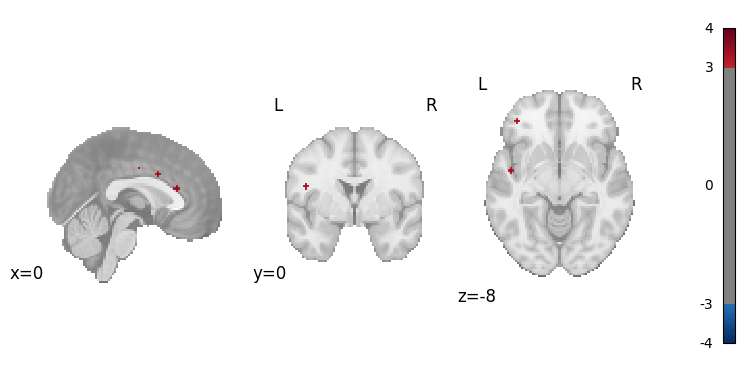

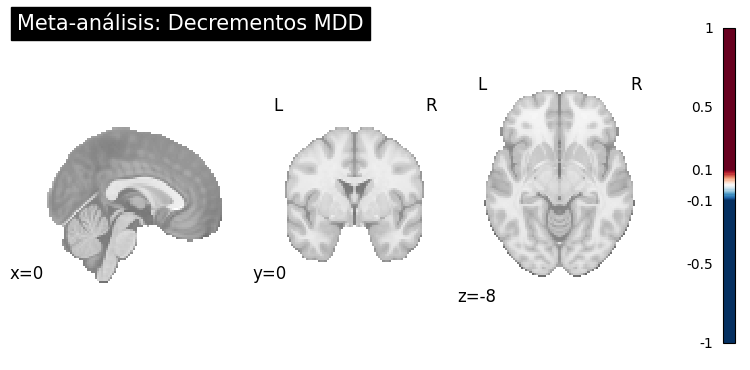

Información estadistica relevante:
--------------------------------------------------
Maximo Z-score SIN FWE: 3.9615771770477295
Máximo Z-score CON FWE: 0.0

Coordenadas exactas de los picos significativos:
Peak Z: 3.9615771770477295
MNI Coordinate: [ 54. -40.  38.]


In [42]:
# Depresion Funcional Decremental
# Primero importar todo lo necesario 
# AL ser funcional se tiene que hacer 

import os
from pprint import pprint
import numpy as np

from nilearn.plotting import plot_stat_map

from nimare.correct import FWECorrector
from nimare.nimads import Studyset
from nimare.utils import get_resource_path
import matplotlib.pyplot as plt
from nimare.meta.cbma.mkda import MKDADensity

# ALE
from nimare.meta.cbma.ale import ALE





studyset_file = "depresion_funcional_decremental.json"
studyset = Studyset(studyset_file, target="mni152_2mm")

print("Información del estudio:")
print("-" * 50)
print(f"ID: {studyset.id}")
print(f"Name: {studyset.name}")
print(f"Number of studies: {len(studyset.studies)}")


#cambiar a dataset
nimare_dset = studyset.to_dataset()
print("\nLegacy Dataset coordinates preview:")
print("-" * 50)
print(nimare_dset.coordinates.head())


## Primero es ALE, Activaation likelihood estimatoin 

meta = ALE()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=100, n_cores=1)
cres = corr.transform(results)

plot_stat_map(
    results.get_map("z"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=3.0,
)
plot_stat_map(
    cres.get_map("z_desc-size_level-cluster_corr-FWE_method-montecarlo"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=0.1,
    title="Meta-análisis: Decrementos MDD"
)

print("Información de los resultados:")
print("-" * 50)
print("Description:")
pprint(results.description_)
plt.show()


print("Información estadistica relevante:")
print("-" * 50)
z_data = cres.get_map("z_level-voxel_corr-FWE_method-montecarlo").get_fdata()
raw_z = results.get_map("z").get_fdata()
print(f"Maximo Z-score SIN FWE: {np.max(raw_z)}")
print(f"Máximo Z-score CON FWE: {np.max(z_data)}")


print("\nCoordenadas exactas de los picos significativos:")
z_map_data = results.get_map("z").get_fdata()
# Find the indices of the maximum value
peak_idx = np.unravel_index(np.argmax(z_map_data, axis=None), z_map_data.shape)
# Convert index to MNI coordinate
peak_coord = results.get_map("z").affine.dot(np.append(peak_idx, 1))[:3]
print(f"Peak Z: {z_map_data[peak_idx]}")
print(f"MNI Coordinate: {peak_coord}")



#### **Info importante**
1. Se genero solamente apartir de la información en donde el cerebro decrementaba 
2. Se genero un threshold mayor, en pro de poder filtrar de forma manual (no depender de un corrector como FWE Para generar esto), como obtuvimos un Z-score de 3.96, se genero un threshold de 3.0 para filtrar de forma correcta las coordenadas con afectación sustancial en el cerebro. 


## **1.2 DEPRESIÓN FUNCIONAL INCREMENTAL**
### Técnina implementada: **ALE** (Activation Likelihood Estimation)

Información del estudio:
--------------------------------------------------
ID: 01 Depr_Funcional_incremental
Name: DEPRESION FUNCIONAL INCREMENTAL 
Number of studies: 3

Legacy Dataset coordinates preview:
--------------------------------------------------
                            id        study_id   contrast_id     x     y     z       space
5  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq  24.0   0.0 -15.0  mni152_2mm
6  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq -21.0   0.0 -24.0  mni152_2mm
7  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq   6.0  42.0 -33.0  mni152_2mm
8  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq   3.0  -3.0 -12.0  mni152_2mm
9  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq  42.0  24.0 -21.0  mni152_2mm


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.
100%|██████████| 100/100 [00:07<00:00, 13.80it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.


Información de los resultados:
--------------------------------------------------
Description:
('An activation likelihood estimation (ALE) meta-analysis '
 '\\citep{turkeltaub2002meta,turkeltaub2012minimizing,eickhoff2012activation} '
 'was performed with NiMARE 0.9.0 (RRID:SCR_017398; \\citealt{Salo2023}), '
 'using a(n) ALE kernel. An ALE kernel \\citep{eickhoff2012activation} was '
 'used to generate study-wise modeled activation maps from coordinates. In '
 'this kernel method, each coordinate is convolved with a Gaussian kernel with '
 'full-width at half max values determined on a study-wise basis based on the '
 'study sample sizes according to the formulae provided in '
 '\\cite{eickhoff2012activation}. For voxels with overlapping kernels, the '
 'maximum value was retained. ALE values were converted to p-values using an '
 'approximate null distribution \\citep{eickhoff2012activation}. The input '
 'dataset included 13 foci from 3 experiments, with a total of 277 '
 'participa

/var/folders/0q/7zh_rqtj2mq1l_7c2wx8byvc0000gn/T/ipykernel_58637/1479541243.py:56: UserWarning: empty mask
  plot_stat_map(


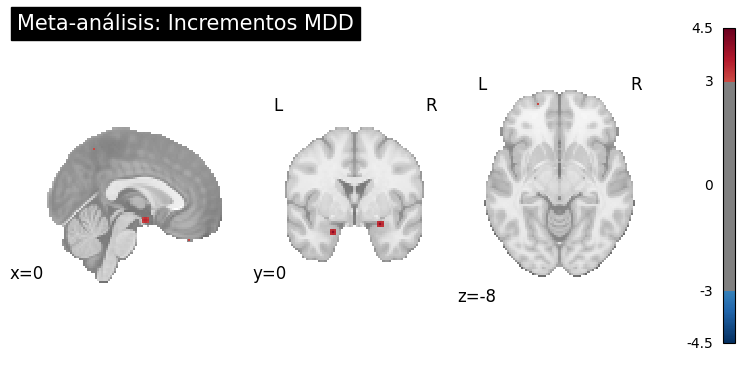

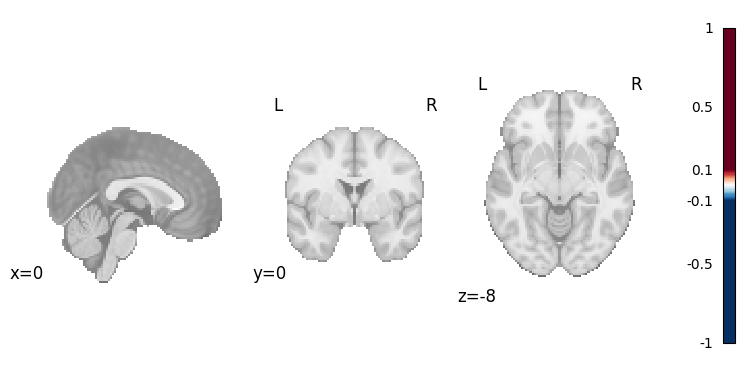

Información estadistica relevante:
--------------------------------------------------
Maximo Z-score SIN FWE: 4.489522933959961
Máximo Z-score CON FWE: 0.0

Coordenadas exactas de los picos significativos:
Peak Z: 4.489522933959961
MNI Coordinate: [-48. -22. -28.]
--------------------------------------------------

Visualización de los resultados en un glass brain:


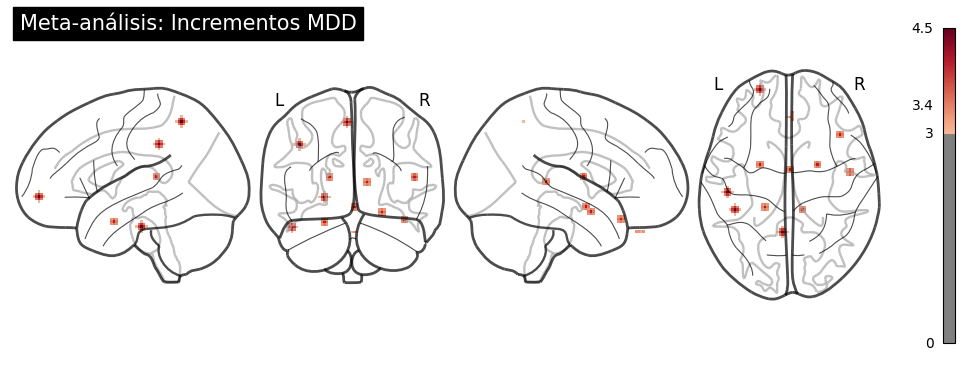

In [ ]:
# Depresion Funcional Incremental

import os
from pprint import pprint
import numpy as np

from nilearn.plotting import plot_stat_map

from nimare.correct import FWECorrector
from nimare.nimads import Studyset
from nimare.utils import get_resource_path
import matplotlib.pyplot as plt
from nimare.meta.cbma.mkda import MKDADensity

# ALE
from nimare.meta.cbma.ale import ALE





studyset_file = "depresion_funcional_incremental.json"
studyset = Studyset(studyset_file, target="mni152_2mm")

print("Información del estudio:")
print("-" * 50)
print(f"ID: {studyset.id}")
print(f"Name: {studyset.name}")
print(f"Number of studies: {len(studyset.studies)}")


#cambiar a dataset
nimare_dset = studyset.to_dataset()
print("\nLegacy Dataset coordinates preview:")
print("-" * 50)
print(nimare_dset.coordinates.head())


## Primero es ALE, Activaation likelihood estimatoin 

meta = ALE()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=100, n_cores=1)
cres = corr.transform(results)

plot_stat_map(
    results.get_map("z"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=3.0,
    title="Meta-análisis: Incrementos MDD"
)
plot_stat_map(
    cres.get_map("z_desc-size_level-cluster_corr-FWE_method-montecarlo"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=0.1,
)

print("Información de los resultados:")
print("-" * 50)
print("Description:")
pprint(results.description_)
plt.show()


print("Información estadistica relevante:")
print("-" * 50)
z_data = cres.get_map("z_level-voxel_corr-FWE_method-montecarlo").get_fdata()
raw_z = results.get_map("z").get_fdata()
print(f"Maximo Z-score SIN FWE: {np.max(raw_z)}")
print(f"Máximo Z-score CON FWE: {np.max(z_data)}")


print("\nCoordenadas exactas de los picos significativos:")
z_map_data = results.get_map("z").get_fdata()
# Find the indices of the maximum value
peak_idx = np.unravel_index(np.argmax(z_map_data, axis=None), z_map_data.shape)
# Convert index to MNI coordinate
peak_coord = results.get_map("z").affine.dot(np.append(peak_idx, 1))[:3]
print(f"Peak Z: {z_map_data[peak_idx]}")
print(f"MNI Coordinate: {peak_coord}")

from nilearn import plotting
print("-" * 50)
print("\nVisualización de los resultados en un glass brain:")
print("-" * 50)

plotting.plot_glass_brain(results.get_map("z"), 
                          display_mode='lyrz', 
                          colorbar=True, 
                          threshold=3.0, 
                          plot_abs=False, # Importante: muestra + y - por separado
                          title="Meta-análisis: Incrementos MDD")

